# AsyncFlow — MMc split Theory vs Simulation (Guided Notebook)

This notebook shows how to:

1. Make imports work inside a notebook (src-layout or package install)
2. Build a **multi-server** scenario compatible with **M/M/c** assumptions in the case of n parallel M/M/1
3. Run the simulation and collect results
4. Compare theory vs observed KPIs (pretty-printed table)
5. Plot the standard dashboards (latency, throughput, server time series)

> Tip: run this notebook from your project **root folder**.


In [ ]:
import sys, importlib


for m in list(sys.modules):
    if m.startswith("asyncflow"):
        del sys.modules[m]


from asyncflow import AsyncFlow, SimulationRunner
from asyncflow.analysis import MMc, ResultsAnalyzer
from asyncflow.components import (
    Client, Server, LinkEdge, Endpoint, LoadBalancer, ArrivalsGenerator
)
from asyncflow.settings import SimulationSettings

import simpy



In [ ]:
import matplotlib.pyplot as plt
import simpy

# Public AsyncFlow API
from asyncflow import AsyncFlow, SimulationRunner, Sweep
from asyncflow.components import Client, Server, LinkEdge, Endpoint, LoadBalancer, ArrivalsGenerator
from asyncflow.settings import SimulationSettings
from asyncflow.analysis import  ResultsAnalyzer, SweepAnalyzer, MMc
from asyncflow.enums import Distribution

print("Imports OK.")

Imports OK.


## 1) Build an M/M/c split-friendly scenario

* **Multiple identical servers with exponential CPU service**
  Topology includes **\$c \geq 2\$ identical servers**, each exposing exactly **one endpoint** with exactly **one CPU-bound step**.
  Service times follow an **Exponential** distribution with mean \$E\[S]\$ (service rate \$\mu = 1/E\[S]\$). No RAM/IO steps are included in the pipeline.

* **Load balancer with round-robin dispatch**
  A **single load balancer** is required when \$c > 1\$. It splits arrivals **randomly** across servers, so each server has its own local queue.
  This corresponds to a **split M/M/c** model, not the textbook pooled queue.

* **“Poisson arrivals” via the generator**
  

  

---

```mermaid
graph LR;
    rqs1["<b>RqsGenerator</b><br/>id: rqs-1"]
    client1["<b>Client</b><br/>id: client-1"]
    lb1["<b>LoadBalancer</b><br/>id: lb-1<br/>Policy: round_robin"]
    app1["<b>Server</b><br/>id: app-1<br/>Endpoint: /api"]
    app2["<b>Server</b><br/>id: app-2<br/>Endpoint: /api"]

    rqs1 -- "Edge: gen-client<br/>Latency: 0.0001" --> client1;
    client1 -- "Request<br/>Edge: client-lb<br/>Latency: 0.0001" --> lb1;
    lb1 -- "Dispatch<br/>Edge: lb-app1<br/>Latency: 0.0001" --> app1;
    lb1 -- "Dispatch<br/>Edge: lb-app2<br/>Latency: 0.0001" --> app2;
    app1 -- "Response<br/>Edge: app1-client<br/>Latency: 0.0001" --> client1;
    app2 -- "Response<br/>Edge: app2-client<br/>Latency: 0.0001" --> client1;
```

---

⚠️ **Note on model scope**
This scenario currently represents a **split M/M/c with random dispatch**.
The **textbook M/M/c (Erlang-C)** assumes a **single pooled FCFS queue feeding c servers**, which tends to give lower waiting times (no imbalance across local queues).

In a future step, we will extend AsyncFlow with a **pooled FCFS dispatcher** at the load balancer, enabling direct comparison against the textbook Erlang-C closed forms.

---



In [ ]:
def build_payload():
    generator = ArrivalsGenerator(
        id="rqs-1",
        lambda_rps=30,
        model=Distribution.POISSON
    )

    client = Client(id="client-1")

    endpoint = Endpoint(
        endpoint_name="/api",
        probability=1.0,
        steps=[
            {
                "kind": "initial_parsing",
                "step_operation": {
                    "cpu_time": {"mean": 0.01, "distribution": "exponential"},
                },
            },
        ],
    )

    srv1 = Server(
        id="srv-1",
        server_resources={"cpu_cores": 1, "ram_mb": 2048},
        endpoints=[endpoint],
    )
    srv2 = Server(
        id="srv-2",
        server_resources={"cpu_cores": 1, "ram_mb": 2048},
        endpoints=[endpoint],
    )

    lb = LoadBalancer(
        id="lb-1",
        algorithms="random",  
        server_covered={"srv-1", "srv-2"},
    )

    edges = [
        LinkEdge(id="gen-client",  source="rqs-1",  target="client-1",),
        LinkEdge(id="client-lb",   source="client-1", target="lb-1",  ),
        LinkEdge(id="lb-srv1",     source="lb-1",   target="srv-1",   ),
        LinkEdge(id="lb-srv2",     source="lb-1",   target="srv-2",   ),
        LinkEdge(id="srv1-client", source="srv-1",  target="client-1",),
        LinkEdge(id="srv2-client", source="srv-2",  target="client-1",),
    ]

    settings = SimulationSettings(
        total_simulation_time=2400,
        sample_period_s=0.05,
    )

    payload = (
        AsyncFlow()
        .add_arrivals_generator(generator)
        .add_client(client)
        .add_servers(srv1, srv2)
        .add_load_balancer(lb)
        .add_edges(*edges)
        .add_simulation_settings(settings)
    ).build_payload()

    return payload


## 2) Run the simulation


In [4]:
payload = build_payload()
env = simpy.Environment()
runner = SimulationRunner(env=env, simulation_input=payload)
results: ResultsAnalyzer = runner.run()
print("Done.")

Done.


## 3) MMc (Random) — theory vs observed comparison

If the payload violates MMc assumptions, a readable error is shown instead.
This section matches exactly what the analyzer computes **now**: a **split random model** (not the pooled FCFS/Erlang-C model). When we add **FCFS** in the LB, we’ll also expose the textbook Erlang-C formulas side-by-side.

---

## Variables (what they represent)

* **$c$**: number of *identical* servers (parallel replicas).
* **$\lambda$**: global **arrival rate** (req/s).
* **$\mu$**: **per-server** service rate (req/s) $= 1/\mathbb{E}[S]$.
* **$\rho$**: **global utilization**, $\rho = \lambda/(c\,\mu)$ (unitless).
* **$W$**: **mean time in system** (queue + service), seconds.
* **$W_q$**: **mean waiting time in queue**, seconds.
* **$L$**: **mean number in system** (queue + service), unitless.
* **$L_q$**: **mean number in queue**, unitless.
* **$\mathbb{E}[S]$**: mean **CPU service time**, seconds.

Derived (random split model):

* **$\lambda_i$**: **per-server arrival rate**, $\lambda_i = \lambda/c$.

> In the comparison table you’ll see two columns: **Theory** (closed-form) and **Observed** (estimates from the run).

---

## How we compute the **Theory** column (MMc with Round-Robin split)

1. **Predicted arrival rate**

$$
\lambda_{\text{Theory}} \;=\; 
\frac{\texttt{avg\_active\_users.mean}\times
      \texttt{avg\_request\_per\_minute\_per\_user.mean}}{60}
$$

2. **Predicted service rate** (from the **CPU exponential step**)

$$
\mu_{\text{Theory}} \;=\; \frac{1}{\mathbb{E}[S]}
$$

3. **Parallelism & utilization**

$$
c \;=\; \text{number of servers}, 
\qquad
\rho_{\text{Theory}} \;=\; \frac{\lambda_{\text{Theory}}}{c\,\mu_{\text{Theory}}}
$$

4. **RR split closed forms** (used by the analyzer today)

If $\rho_{\text{Theory}} \ge 1$: the system is **unstable** and
$W, W_q, L, L_q$ **diverge** (displayed as $+\infty$).

Otherwise, let $\lambda_i = \lambda_{\text{Theory}}/c$. We use:

$$
\begin{aligned}
W_{q,\text{Theory}} &= \frac{\rho_{\text{Theory}}}
                            {\mu_{\text{Theory}} - \lambda_i} \\
W_{\text{Theory}}   &= \frac{1}{\mu_{\text{Theory}}} + W_{q,\text{Theory}} \\
L_{q,\text{Theory}} &= \lambda_{\text{Theory}} \, W_{q,\text{Theory}} \\
L_{\text{Theory}}   &= \lambda_{\text{Theory}} \, W_{\text{Theory}}
\end{aligned}
$$

> 🔎 **Note:** These formulas reflect a **random split** into *c* identical M/M/1 queues (no central pool). They are **not** the Erlang-C (pooled FCFS) formulas. Once we add **FCFS** at the LB, we’ll surface the **textbook pooled M/M/c** KPIs (including $P_0$, $P_w$, etc.) alongside this random split model.

---

## How we compute the **Observed** column (from the run)

After `ResultsAnalyzer.process_all_metrics()`:

1. **Observed arrival rate** (system throughput)

$$
\lambda_{\text{Observed}} \;=\; 
\text{mean}\big(\text{windowed RPS series (client completions)}\big)
$$

*(This is end-to-end, i.e., what exits all servers and reaches the client.)*

2. **Observed time in system** (client E2E latency)

$$
W_{\text{Observed}} \;=\; \text{mean}\big(\text{client latencies}\big)
$$

3. **Observed service rate** (aggregate across servers)
   Let $\overline{S} = \text{mean}(\texttt{service\_time})$ *over all servers, weighted by number of jobs*:

$$
\mu_{\text{Observed}} \;=\;
\begin{cases}
1/\overline{S}, & \overline{S} > 0 \\
+\infty, & \overline{S} = 0
\end{cases}
$$

4. **Observed waiting time in queue** (aggregate across servers)

$$
W_{q,\text{Observed}} \;=\; 
\text{mean}\big(\texttt{waiting\_time}\big)
$$

5. **Little’s law (observed)**

$$
L_{\text{Observed}}=\lambda_{\text{Observed}}\, W_{\text{Observed}},
\qquad
L_{q,\text{Observed}}=\lambda_{\text{Observed}}\, W_{q,\text{Observed}}
$$

6. **Observed utilization (global)**

$$
\rho_{\text{Observed}} \;=\;
\begin{cases}
\lambda_{\text{Observed}} / (c\,\mu_{\text{Observed}}),
 & \mu_{\text{Observed}} \not\in \{0, +\infty\} \\
0, & \text{otherwise}
\end{cases}
$$

---

### Why small deltas appear

* **Finite horizon / warm-up:** Short runs and lack of warm-up bias early windows.


In [5]:
mmc = MMc()
if mmc.is_compatible(payload):
   mmc.print_comparison(payload, results)  
else:
    print("Payload is not compatible with M/M/c:")
    for reason in mmc.explain_incompatibilities(payload):
        print(" -", reason)
   


MMc (RR) — Theory vs Observed
------------------------------------------------------------------
sym  metric                    theory   observed        abs   rel%
------------------------------------------------------------------
λ    Arrival rate (1/s)     30.000000  30.041250   0.041250   0.14
μ    Service rate (1/s)    100.000000  99.914401  -0.085599  -0.09
c    Servers                 2.000000   2.000000   0.000000   0.00
rho  Utilization             0.150000   0.150335   0.000335   0.22
L    Mean items in sys       0.352941   0.355440   0.002499   0.71
Lq   Mean items in queue     0.052941   0.053568   0.000627   1.18
W    Mean time in sys (s)    0.011765   0.011832   0.000067   0.57
Wq   Mean waiting (s)        0.001765   0.001783   0.000018   1.05


### 4) Plot dashboards

**System-level and per-server charts**

Beyond the two main panels (latency histogram + throughput time series), AsyncFlow records **rich time series and per-request distributions** that make the system behavior easy to read. In your scenario (single server, exponential CPU only, no I/O/RAM), you’ll see:

* **System dashboard**

  * **Request Latency Distribution**: end-to-end histogram (client→server→client) with **mean, P50, P95, P99** markers. Here latency is dominated by CPU service + short queue; vertical lines highlight tail behavior.
  * **Throughput (RPS)**: windowed time series with **mean, P95, max**. Great for spotting stability, oscillations, and warm-up.

* **Server time-series dashboard (for `app-1`)**

  * **Ready queue length**: CPU queue over time with **mean/min/max**. With ρ≈0.5 the mean queue ≈0.5, consistent with M/M/1.
  * **I/O queue length**: flat at zero (no I/O step in the pipeline).
  * **RAM in use**: flat at zero (no RAM step in the pipeline).

* **Server event-metrics dashboard**

  * **Server-side latency**: histogram of (waiting + service) at the server.
  * **CPU service time**: histogram of **service\_time** (Exp \~15 ms) with P95/P99.
  * **CPU waiting time**: histogram of queue **waiting\_time**; shows the heavy tail under bursts.
  * **I/O time**: flat at zero (no I/O).

#### What you “get for free” from the collected data

* **Distributions** (per-request arrays): end-to-end latency, server latency, **service\_time**, **waiting\_time**, (optional) **io\_time** ⇒ percentiles, variance, pre/post comparisons.
* **Time series** (periodic sampling): **ready\_queue\_len**, **event\_loop\_io\_sleep** (if I/O exists), **ram\_in\_use**, **edge\_concurrent\_connection**, plus **throughput series** to estimate observed λ.
* **Derived checks**: automatic **Little’s Law** sanity (L≈λW, Lq≈λWq), observed utilization **ρ̂ = λ̂/μ̂**, and the **MM1 theory vs observed** comparison table you printed.

> In this specific setup, I/O and RAM panels are flat by design; add I/O or RAM steps and those plots will populate accordingly.


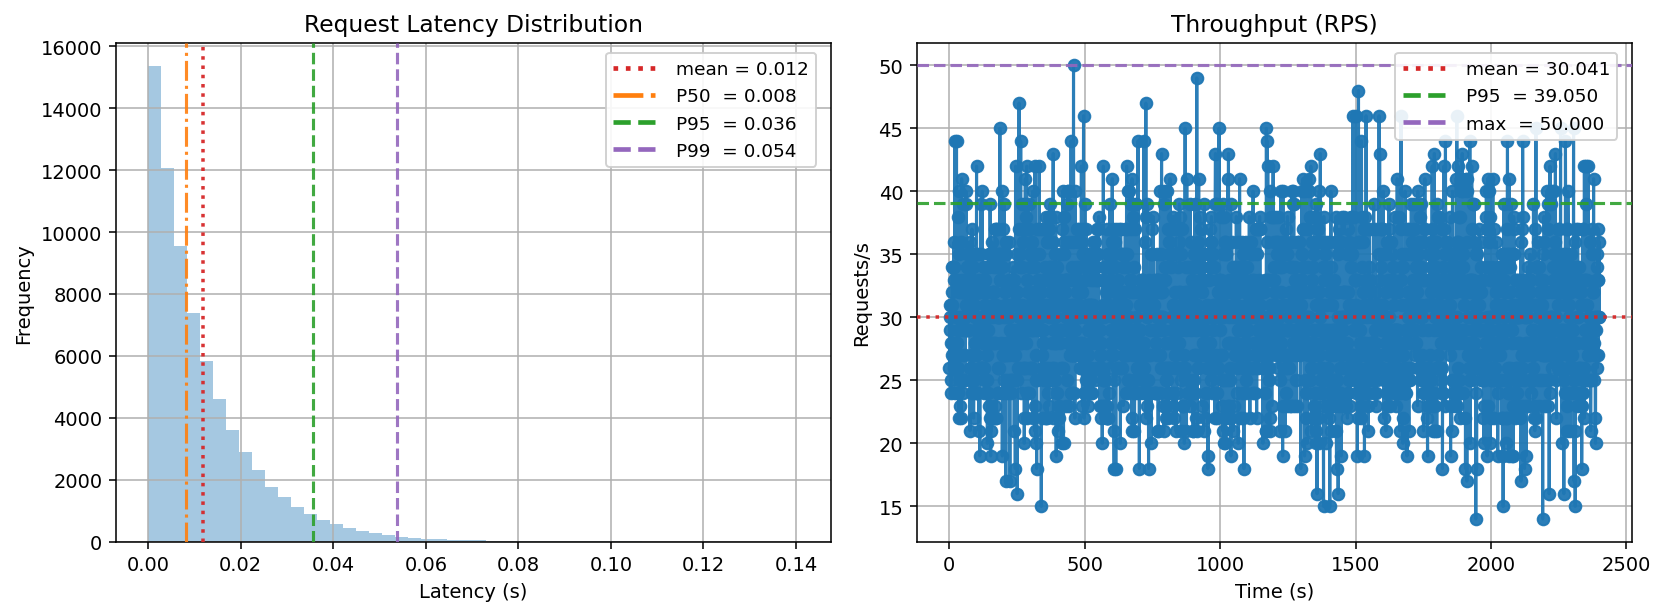

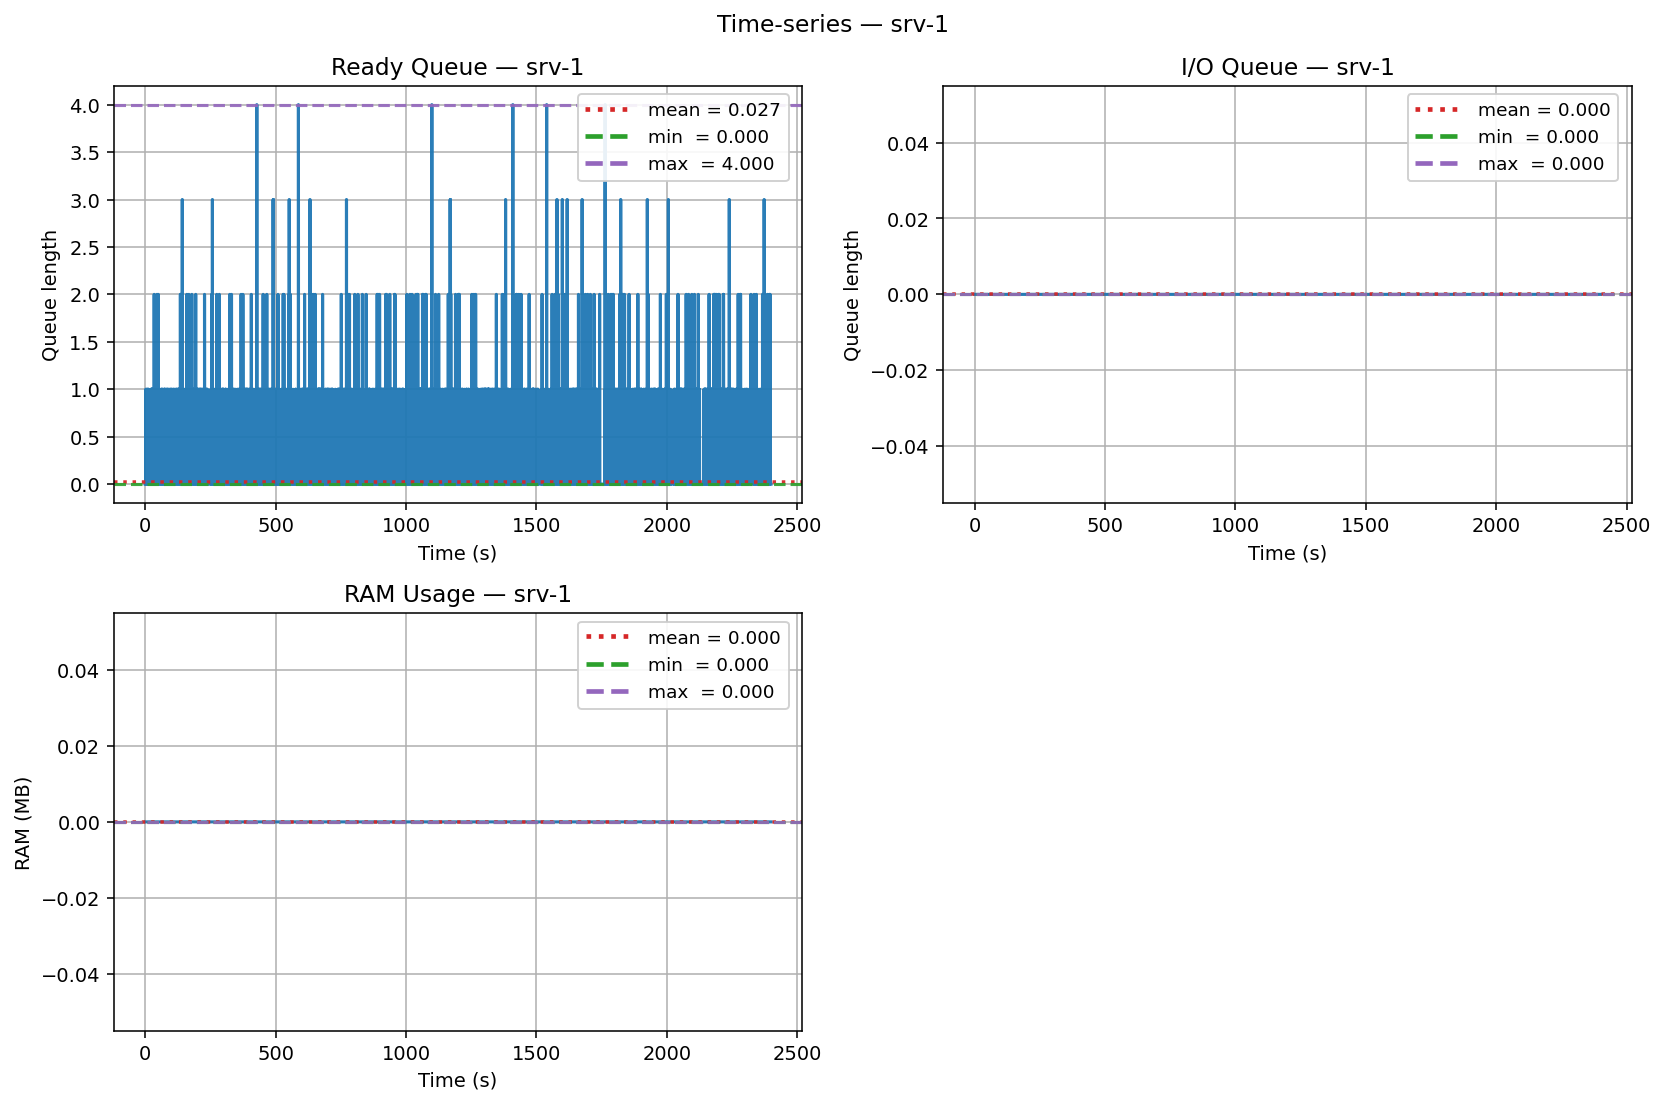

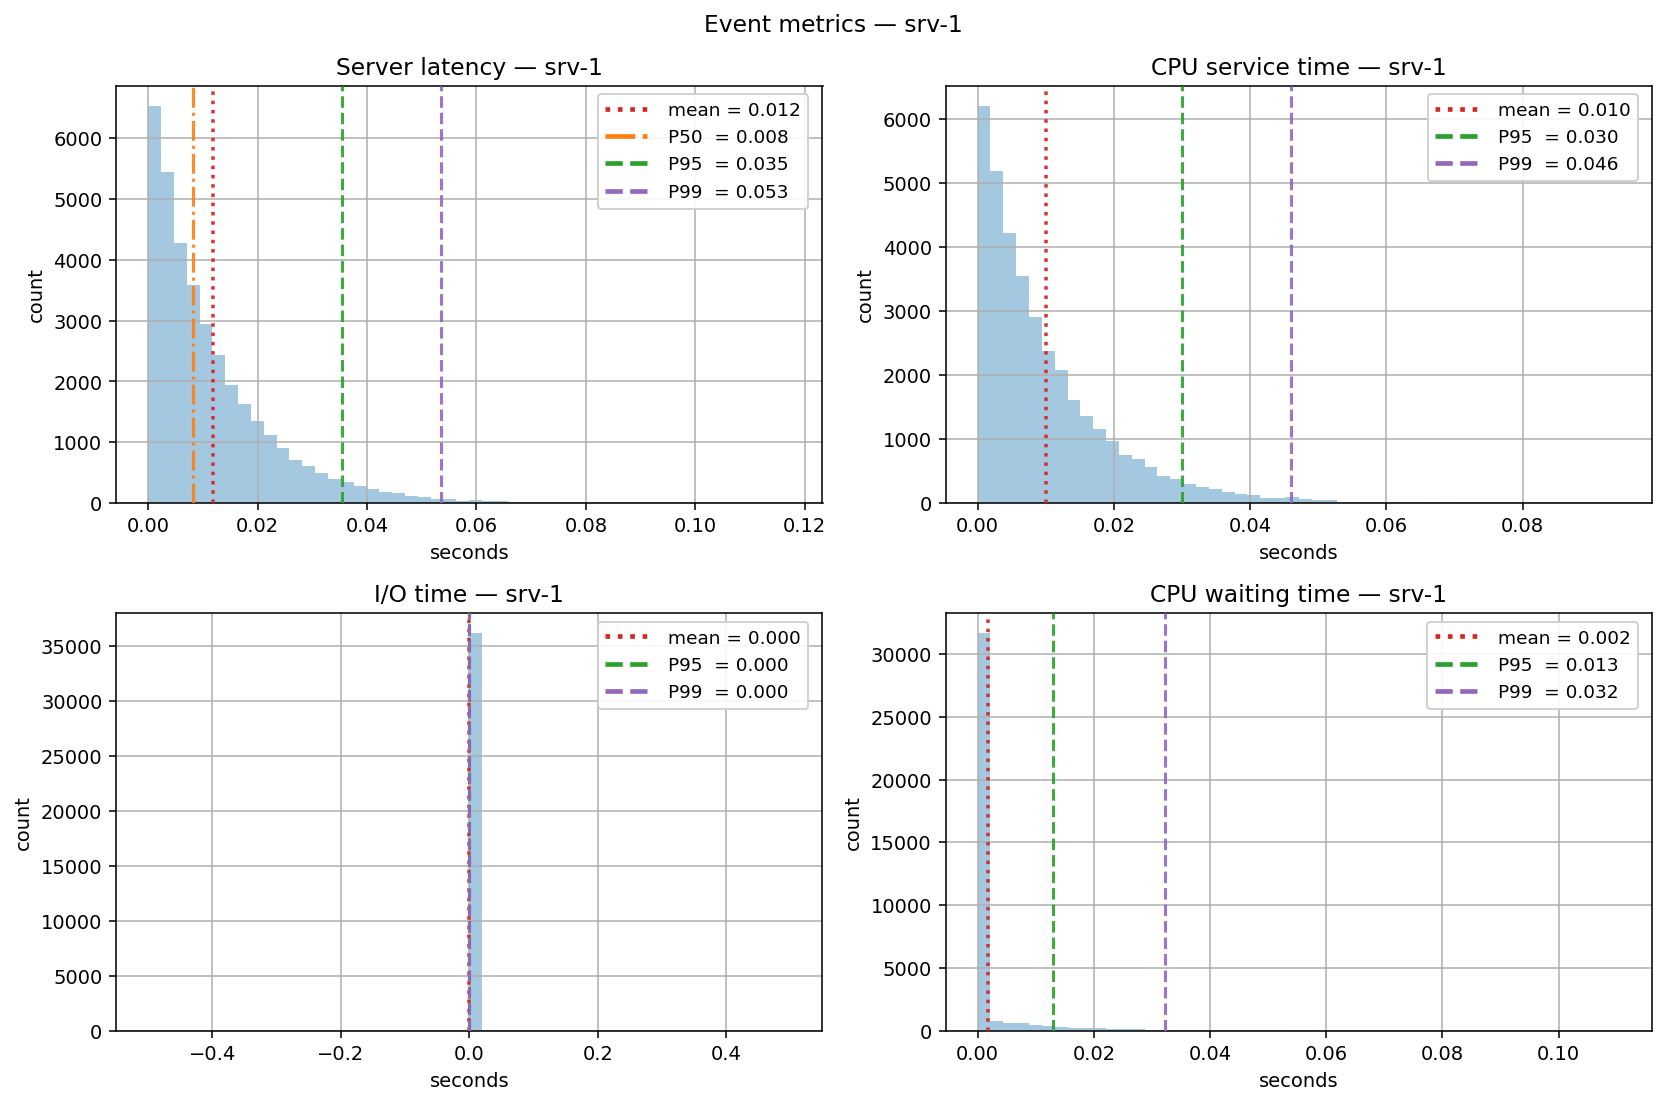

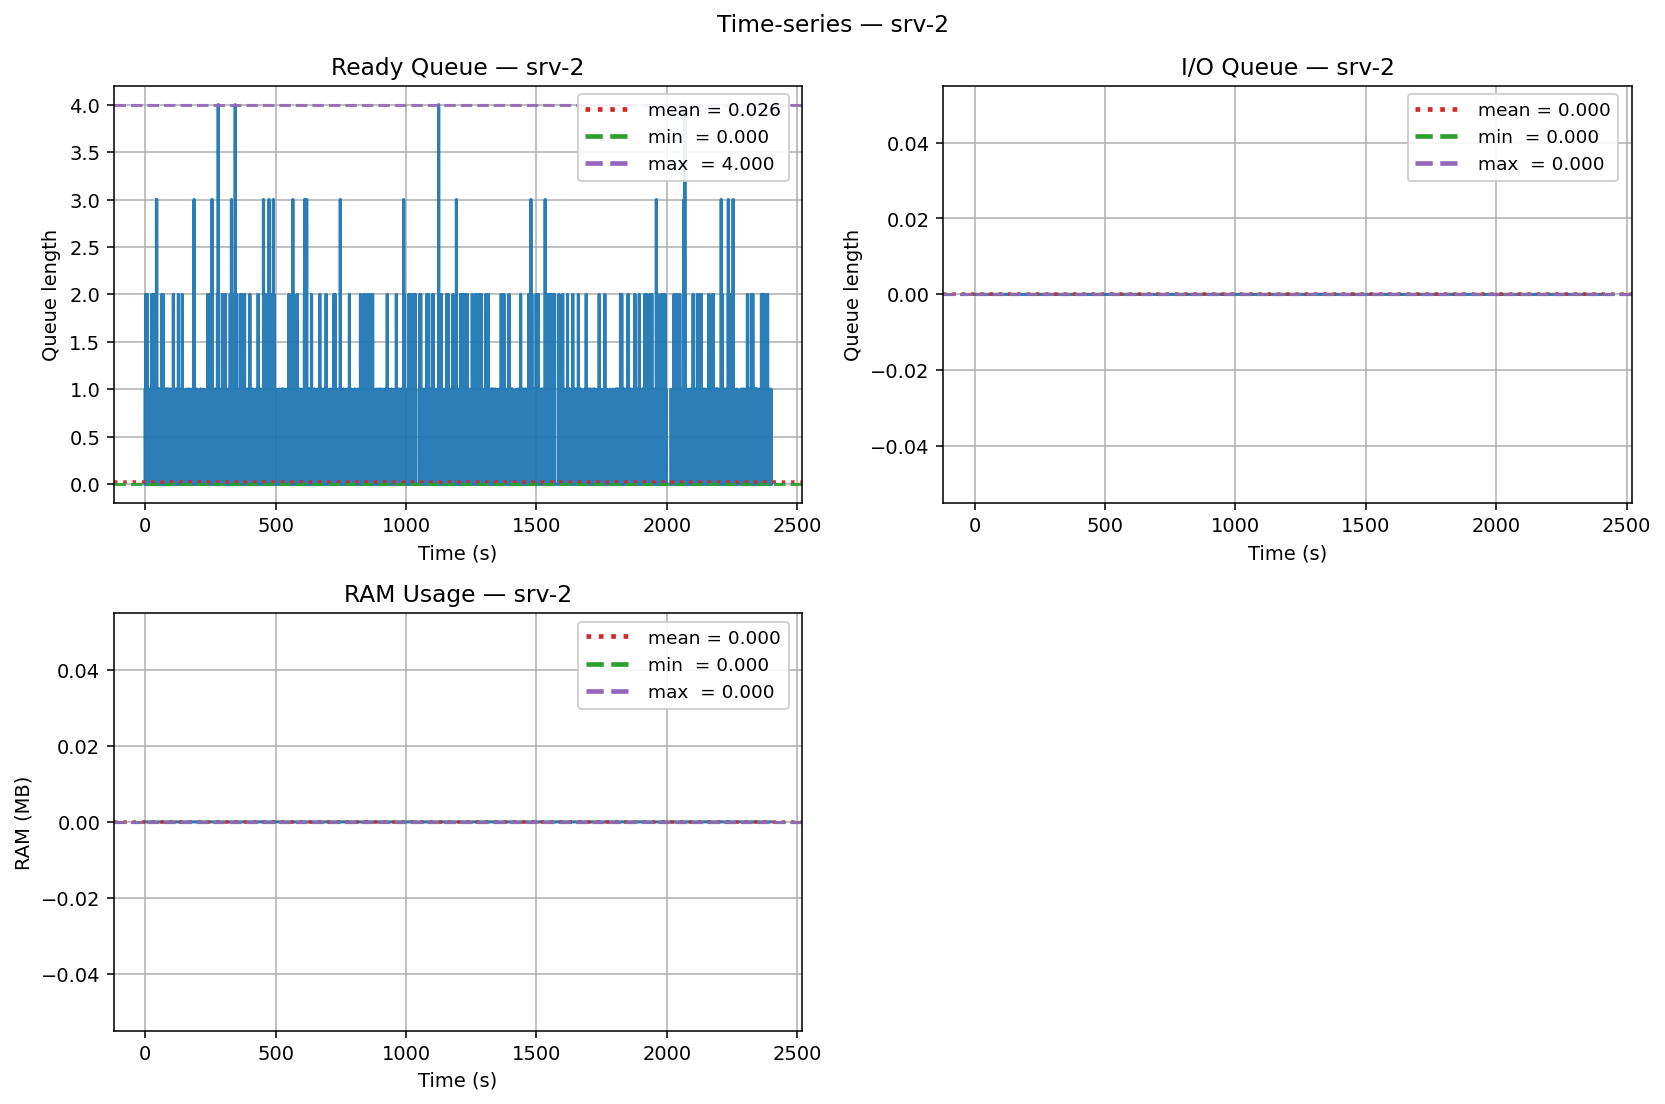

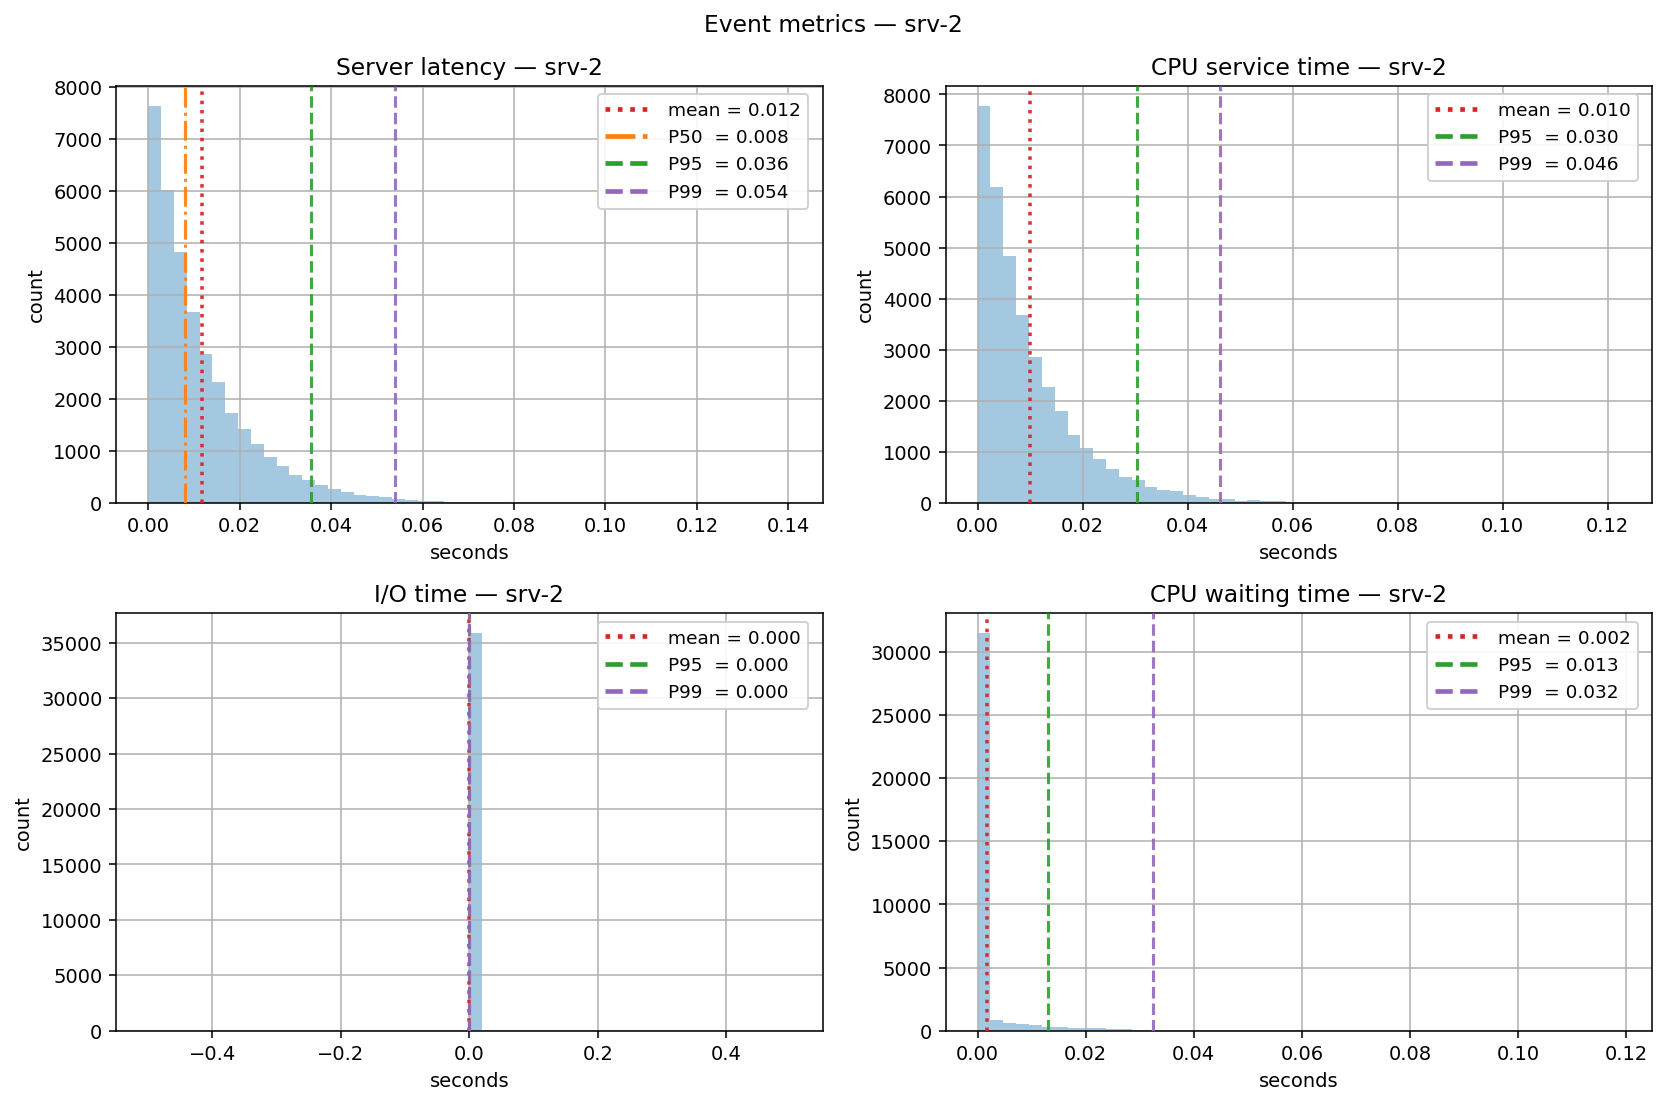

In [6]:
# 4.1 System dashboard: latency + throughput
fig_sys, axes_sys = plt.subplots(1, 2, figsize=(12, 4.5), dpi=140)
results.plot_latency_distribution(axes_sys[0])
results.plot_throughput(axes_sys[1])
fig_sys.tight_layout()
plt.show()

# 4.2 Server time-series and event-metric dashboards
sids = results.list_server_ids()
for sid in sids:
    # --- dashboards ---
    fig_ts, axes_ts = plt.subplots(2, 2, figsize=(12, 8), dpi=140)
    axes_ts[1, 1].axis("off")
    results.plot_server_timeseries_dashboard(
        ax_ready=axes_ts[0, 0],
        ax_io=axes_ts[0, 1],
        ax_ram=axes_ts[1, 0],
        server_id=sid,
    )
    fig_ts.suptitle(f"Time-series — {sid}")
    fig_ts.tight_layout()
    plt.show()

    fig_ev, axes_ev = plt.subplots(2, 2, figsize=(12, 8), dpi=140)
    results.plot_server_event_metrics_dashboard(
        ax_latency_hist=axes_ev[0, 0],
        ax_service_hist=axes_ev[0, 1],
        ax_io_hist=axes_ev[1, 0],
        ax_wait_hist=axes_ev[1, 1],
        server_id=sid,
    )
    fig_ev.suptitle(f"Event metrics — {sid}")
    fig_ev.tight_layout()
    plt.show()

